# Stock Market Crash Prediction Using S&P 500 and VIX

## Introduction

Financial market crashes are among the most impactful events in modern economics. They can lead to substantial losses for investors, institutions, and entire economies.

The purpose of this project is to investigate whether machine learning models can identify patterns that precede significant market downturns.

We focus on the S&P 500 index as a representation of the U.S. equity market and the VIX index as a measure of market fear and expected volatility.

The objective is to predict whether a market crash will occur within the next 10 trading days.


## Problem Statement

Given historical information about:

- S&P 500 prices
- Trading volume
- Market volatility through VIX
- Technical indicators
- Rolling risk measures

Can we predict whether the market will experience a significant decline during the next 10 trading days?

In this project, a "crash" event is defined as a future 10-day return less than or equal to -5%.


## Mathematical Background

### Daily Return

Daily return measures the percentage change in asset price between two consecutive trading sessions.

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

### Future Return

The target variable is based on the future 10-day return:

$$
R_{t,t+10} = \frac{P_{t+10}}{P_t} - 1
$$

### Crash Label

$$
Crash_t = \mathbb{1}(R_{t,t+10} \leq -0.05)
$$

### Volatility

Volatility measures the dispersion of returns and is often used as a proxy for risk.

$$
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(r_i - \mu)^2}
$$

### Logistic Regression

Logistic regression estimates the probability of a crash event:

$$
P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}
$$

## 1. Setup

Install missing packages if needed:

```bash
pip install yfinance ta xgboost
```


In [134]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 100)


## 2. Data Collection

I will use Yahoo Finance through the `yfinance` Python package.

Assets:

- `^GSPC`: S&P 500 index
- `^VIX`: CBOE Volatility Index


In [135]:
start_date = "1990-01-01"
end_date = "2026-01-01"

sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False, auto_adjust=False)
vix = yf.download("^VIX", start=start_date, end=end_date, progress=False, auto_adjust=False)

if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

## 3. Data Preparation

The two time series are joined by date. I keep only dates available for both indices.


In [136]:
sp500 = sp500[["Open", "High", "Low", "Close", "Volume"]].copy()
vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"})

data = sp500.join(vix, how="inner")
data = data.dropna()

data.head()


Price,Open,High,Low,Close,Volume,VIX_Close
Date,,,,,,
1990-01-02,353.399994,359.690002,351.980011,359.690002,162070000,17.240000
1990-01-03,359.690002,360.589996,357.890015,358.760010,192330000,18.190001
1990-01-04,358.760010,358.760010,352.890015,355.670013,177000000,19.219999
1990-01-05,355.670013,355.670013,351.350006,352.200012,158530000,20.110001
1990-01-08,352.200012,354.239990,350.540009,353.790009,140110000,20.260000


## 4. Feature Engineering

I create features that capture trend, momentum, volatility, and market stress.


In [137]:
# Basic returns
data["Return"] = data["Close"].pct_change()
data["VIX_Return"] = data["VIX_Close"].pct_change()

# Trend indicators
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()
data["SMA_200"] = data["Close"].rolling(200).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()
data["EMA_50"] = data["Close"].ewm(span=50, adjust=False).mean()

# Momentum features
data["Momentum_10"] = data["Close"].pct_change(10)
data["Momentum_20"] = data["Close"].pct_change(20)
data["Momentum_60"] = data["Close"].pct_change(60)

# Rolling volatility
data["Volatility_20"] = data["Return"].rolling(20).std()
data["Volatility_60"] = data["Return"].rolling(60).std()

# Drawdown features
rolling_max_252 = data["Close"].rolling(252).max()
data["Drawdown"] = data["Close"] / rolling_max_252 - 1

data["Distance_From_SMA_200"] = data["Close"] / data["SMA_200"] - 1

data.tail()


Price,Open,High,Low,Close,Volume,VIX_Close,Return,VIX_Return,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,Momentum_10,Momentum_20,Momentum_60,Volatility_20,Volatility_60,Drawdown,Distance_From_SMA_200
Date,,,,,,,,,,,,,,,,,,,,
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,13.47,0.003221,-0.037857,6842.541968,6784.985977,6260.738538,6830.374860,6769.943258,0.006588,0.024560,0.036419,0.005743,0.008133,0.000000,0.107226
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,13.60,-0.000304,0.009651,6848.408472,6790.163574,6267.391738,6839.857248,6776.217637,0.004194,0.017222,0.032593,0.005592,0.008125,-0.000304,0.105714
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,14.20,-0.003492,0.044118,6851.240991,6795.696982,6274.312839,6846.131818,6781.296955,0.011473,0.008271,0.028351,0.005568,0.008142,-0.003795,0.100637
2025-12-30,6900.439941,6913.250000,6893.470215,6896.240234,3309930000,14.33,-0.001376,0.009155,6855.421509,6800.341592,6280.599341,6850.904049,6785.804534,0.011697,0.012273,0.026870,0.005422,0.008145,-0.005166,0.098023
2025-12-31,6898.819824,6901.419922,6844.549805,6845.500000,3261830000,14.95,-0.007358,0.043266,6856.228003,6802.548994,6286.451240,6850.389377,6788.145533,0.006653,0.002362,0.015611,0.005685,0.008197,-0.012485,0.088929


## 5. Target Variable: Crash Definition

The target is equal to 1 when the S&P 500 drops at least 5% over the next 10 trading days.


In [138]:
future_horizon = 10
crash_threshold = -0.05

data["Future_10D_Return"] = data["Close"].shift(-future_horizon) / data["Close"] - 1
data["Crash"] = (data["Future_10D_Return"] <= crash_threshold).astype(int)

data = data.dropna()

print(data["Crash"].value_counts())
print(data["Crash"].value_counts(normalize=True))


Crash
0    8417
1     389
Name: count, dtype: int64
Crash
0    0.955826
1    0.044174
Name: proportion, dtype: float64


## 6. Exploratory Data Analysis

I examine the relationship between market price, volatility, and crash labels.


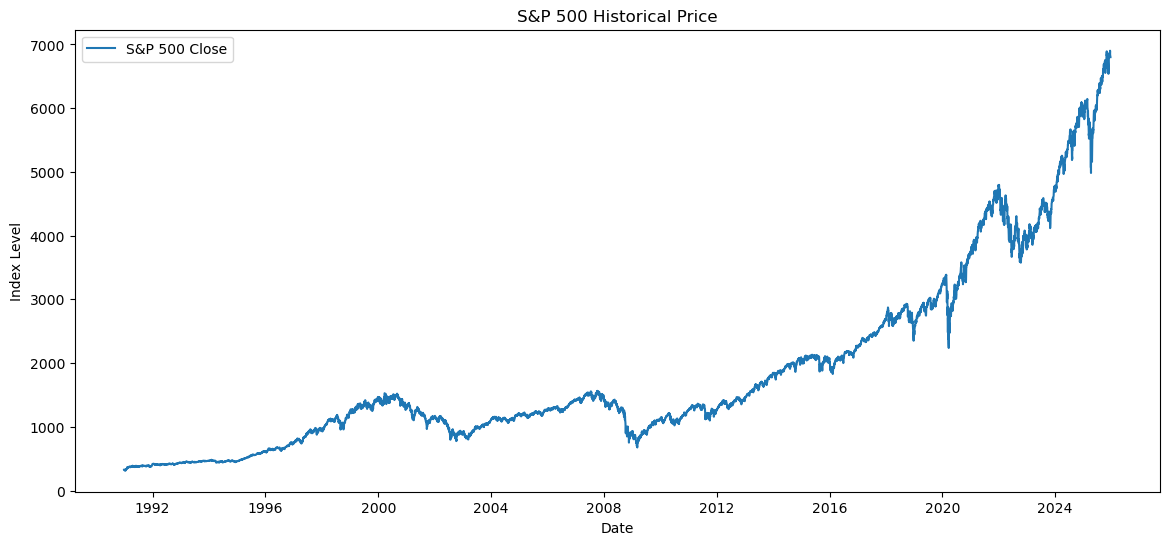

In [139]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label="S&P 500 Close")
plt.title("S&P 500 Historical Price")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()


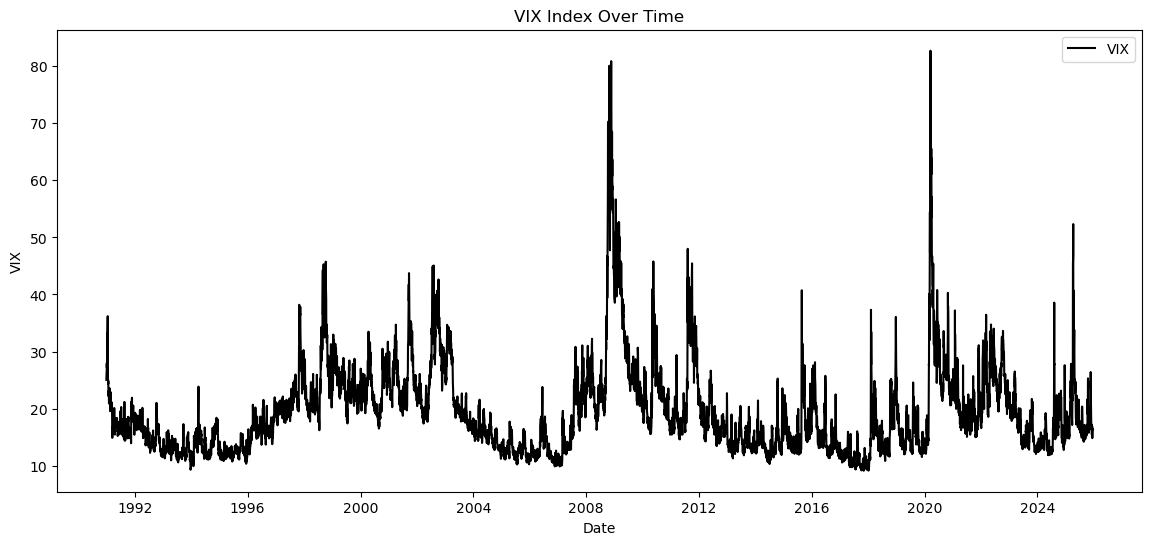

In [140]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["VIX_Close"], label="VIX", color="black")
plt.title("VIX Index Over Time")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.show()


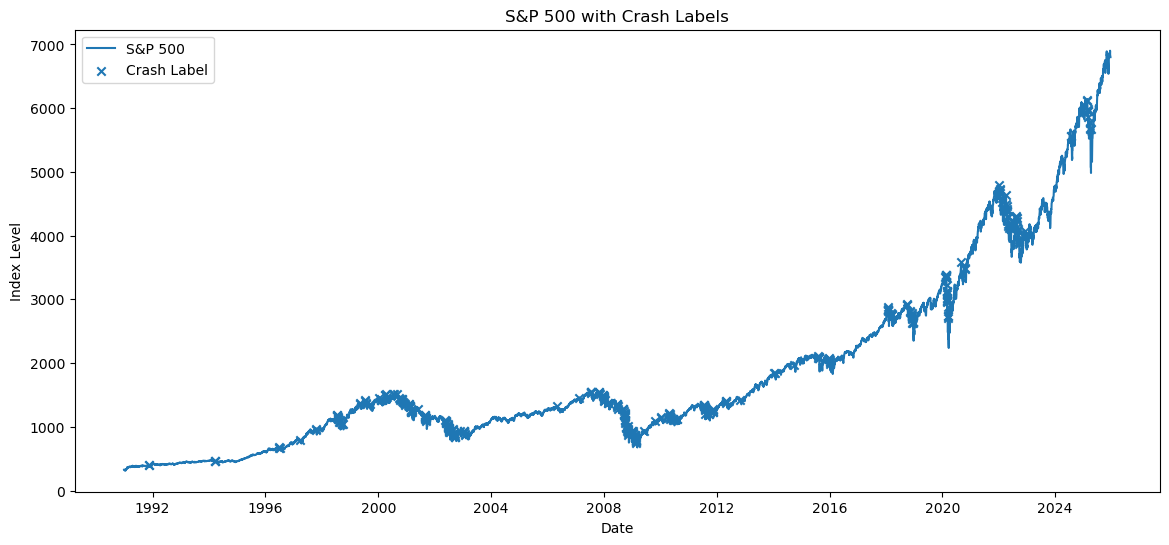

In [141]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label="S&P 500")
crash_points = data[data["Crash"] == 1]
plt.scatter(crash_points.index, crash_points["Close"], marker="x", label="Crash Label")
plt.title("S&P 500 with Crash Labels")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()


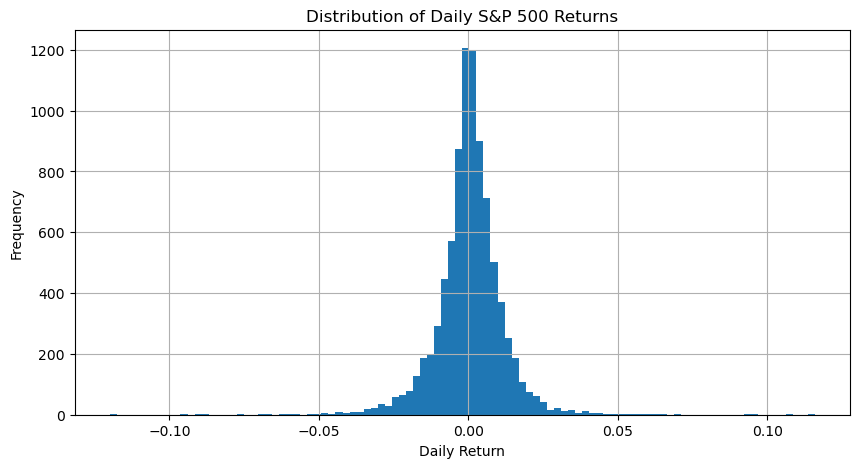

In [142]:
plt.figure(figsize=(10, 5))
data["Return"].hist(bins=100)
plt.title("Distribution of Daily S&P 500 Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


## 7. Feature Selection


In [143]:
features = [
    "Return",
    "VIX_Close",
    "VIX_Return",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "EMA_20",
    "EMA_50",
    "Momentum_10",
    "Momentum_20",
    "Momentum_60",
    "Volatility_20",
    "Volatility_60",
    "Drawdown",
    "Distance_From_SMA_200"
]

X = data[features].copy()
y = data["Crash"].copy()

X.head()


Price,Return,VIX_Close,VIX_Return,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,Momentum_10,Momentum_20,Momentum_60,Volatility_20,Volatility_60,Drawdown,Distance_From_SMA_200
Date,,,,,,,,,,,,,,,
1990-12-28,0.001310,25.049999,0.009674,328.349503,318.972802,334.345000,327.100614,322.521026,-0.001883,0.038872,0.055620,0.007380,0.010625,-0.109039,-0.016824
1990-12-31,0.004563,26.379999,0.053094,328.749503,319.462402,334.286550,327.397698,322.822947,0.010403,0.024828,0.056062,0.006339,0.010627,-0.104974,-0.012165
1991-01-02,-0.011417,26.620001,0.009098,328.867003,319.741802,334.201151,327.307443,322.965185,0.001319,0.007251,0.047994,0.006836,0.010730,-0.115192,-0.023193
1991-01-03,-0.013907,27.930000,0.049211,328.645003,319.884802,334.102850,326.793401,322.923805,-0.024663,-0.013605,0.026892,0.007354,0.010872,-0.127497,-0.036494
1991-01-04,-0.002827,27.190001,-0.026495,328.199002,320.057602,334.009151,326.241648,322.848362,-0.027862,-0.027037,0.052114,0.006837,0.010279,-0.129963,-0.038948


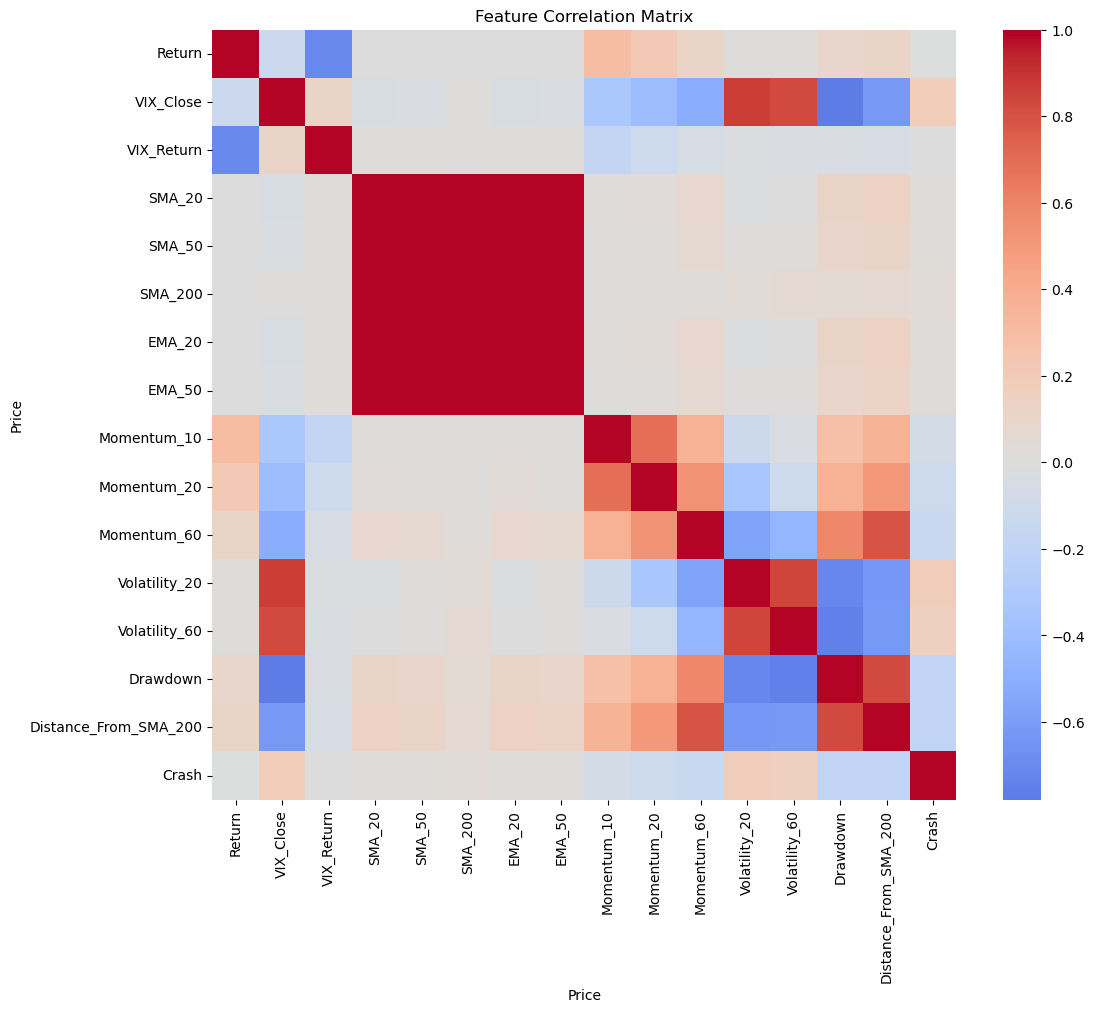

In [144]:
plt.figure(figsize=(12, 10))
sns.heatmap(data[features + ["Crash"]].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


## 8. Time-Series Train/Test Split

Since this is a time-series problem, we do not randomly shuffle the data. The first 80% of observations are used for training and the last 20% for testing.


In [145]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train period:", X_train.index.min(), "to", X_train.index.max())
print("Test period:", X_test.index.min(), "to", X_test.index.max())
print("Train crash rate:", y_train.mean())
print("Test crash rate:", y_test.mean())


Train period: 1990-12-28 00:00:00 to 2018-12-12 00:00:00
Test period: 2018-12-13 00:00:00 to 2025-12-16 00:00:00
Train crash rate: 0.04287336740488359
Test crash rate: 0.04937570942111237


## 9. Model Evaluation Helper


In [146]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"Model: {model_name}")
    print("-" * 60)
    print(classification_report(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("Average Precision:", average_precision_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


## 10. Model 1: Logistic Regression

Logistic Regression is used as an interpretable baseline model.


Model: Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1675
           1       0.05      1.00      0.09        87

    accuracy                           0.05      1762
   macro avg       0.02      0.50      0.05      1762
weighted avg       0.00      0.05      0.00      1762

ROC-AUC: 0.6604014410705095
Average Precision: 0.07543316977251872


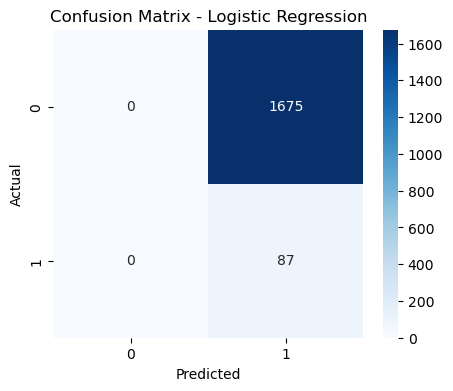

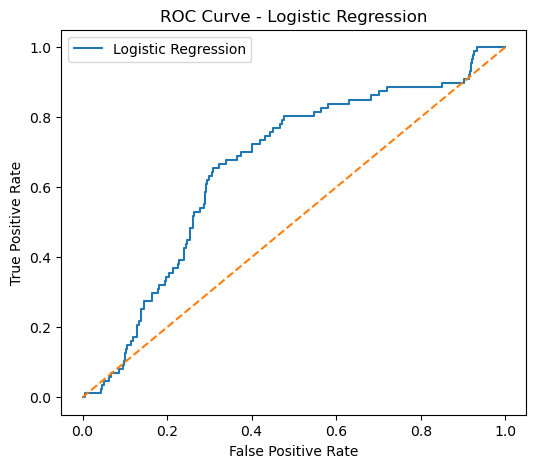

In [147]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, log_preds, log_probs)


## 11. Model 2: Random Forest

Random Forest can capture nonlinear relationships between technical indicators and crash risk.


Model: Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.78      0.86      1675
           1       0.10      0.47      0.16        87

    accuracy                           0.76      1762
   macro avg       0.53      0.62      0.51      1762
weighted avg       0.92      0.76      0.83      1762

ROC-AUC: 0.6701801338136901
Average Precision: 0.12424378895082239


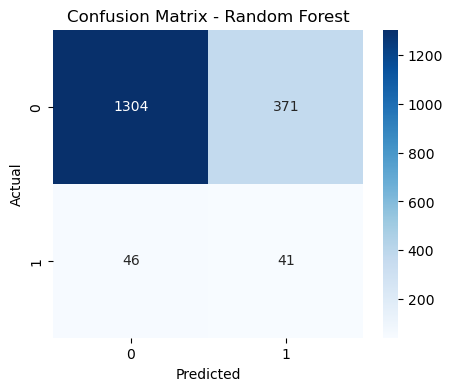

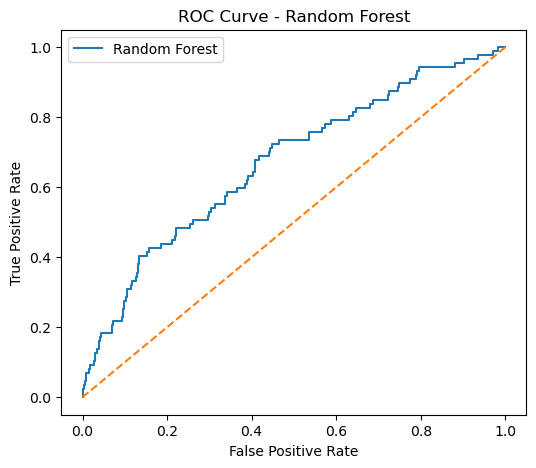

In [148]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_preds, rf_probs)


## 12. Model 3: XGBoost

XGBoost is a powerful gradient boosting method often used for structured data problems.


Model: XGBoost
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.45      0.61      1675
           1       0.04      0.48      0.08        87

    accuracy                           0.45      1762
   macro avg       0.49      0.47      0.34      1762
weighted avg       0.90      0.45      0.58      1762

ROC-AUC: 0.4443369360096071
Average Precision: 0.04303980202201625


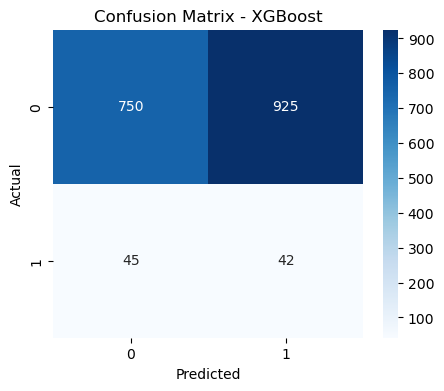

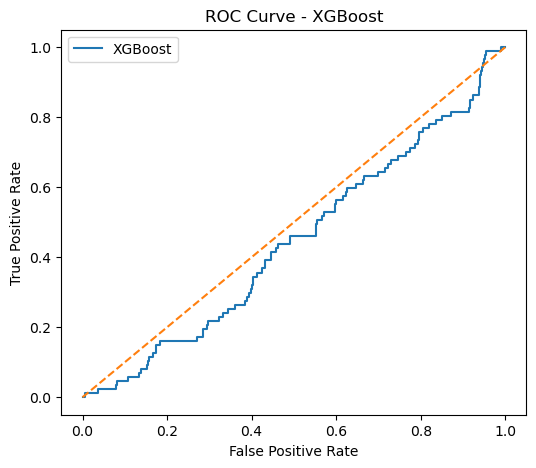

In [149]:
if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    xgb_preds = xgb_model.predict(X_test)
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

    evaluate_model("XGBoost", y_test, xgb_preds, xgb_probs)
else:
    print("XGBoost is not installed. Run: pip install xgboost")


## 13. Feature Importance


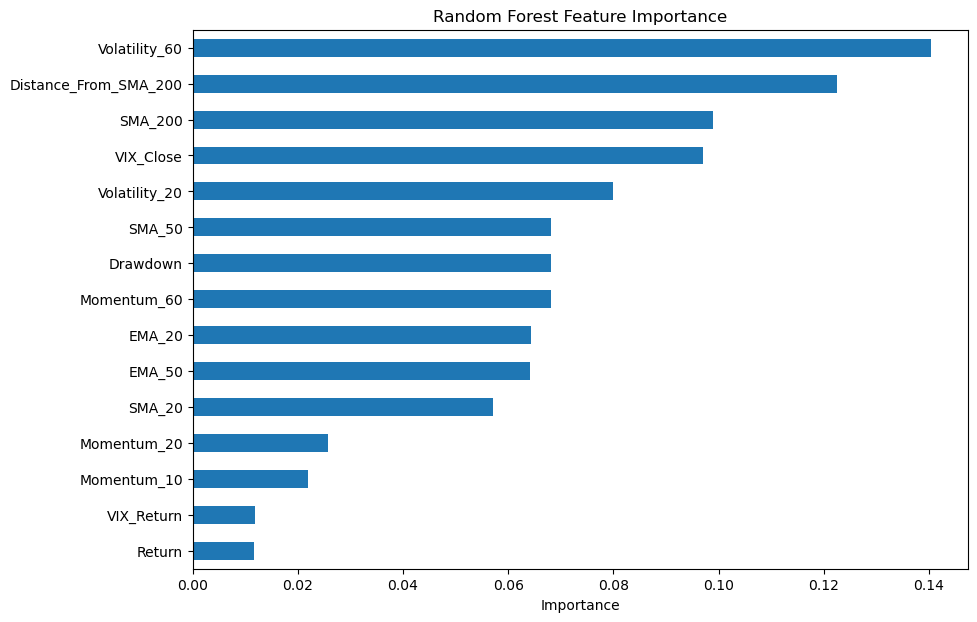

In [150]:
rf_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(10, 7))
rf_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()


## 14. Discussion

This project demonstrates the difficulty of predicting rare financial crash events. Since crashes are uncommon, accuracy alone is not an appropriate metric. Recall, precision, F1-score, ROC-AUC, and average precision provide more meaningful insight.

Important expected findings:

- VIX-related features should carry predictive information.
- Volatility and drawdown features are likely more useful than simple price levels.
- False negatives are more dangerous than false positives in risk management.
- Market regimes change, so historical relationships may not remain stable.


## 15. Limitations

- Market crashes are rare and the dataset is imbalanced.
- Historical relationships may not hold in future market regimes.
- Black Swan events are difficult or impossible to predict reliably.
- VIX data starts in 1990, limiting the historical sample.
- The model does not include macroeconomic variables, interest rates, credit spreads, or news sentiment.
